In [1]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/start')
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/start/Spectral_Maxwell')
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu')
import jax.numpy as jnp
from matplotlib.colors import LogNorm,Normalize
from Spectral_Maxwell.spectrum import get_spectrum_from_field_with_coordinate,filter_spectrum_by_k_coordinate,get_field_from_spectrum_with_coordinate
from plot.plot_2D import plot_2D_field, plot_2D_spectrum

In [2]:
def heat(t,x):
    return jnp.exp(-x**2/t)/jnp.sqrt(jnp.pi*t)

In [3]:
def heat_FT(t,kx):
    return jnp.exp(-t*kx**2/4)

In [4]:
t_coordinate=jnp.linspace(0, 10, 100,endpoint=False)+0.1
x_coordinate=jnp.linspace(-20, 20, 501,endpoint=True)
t_grid,x_grid=jnp.meshgrid(t_coordinate,x_coordinate,indexing='ij')
field_1=heat(t_grid,x_grid)

figure size= [24.3 11.5] inch
ax_main position= Bbox(x0=0.1646090534979424, y0=0.08695652173913043, x1=0.9053497942386831, y1=0.6086956521739131)


{'fig': <Figure size 2430x1150 with 4 Axes>,
 'ax_main': <Axes: xlabel='$x$', ylabel='$t$'>,
 'ax_panel_top': <Axes: xlabel='$x$', ylabel='$h(t,x)$'>,
 'ax_panel_left': <Axes: xlabel='$h(t,x)$', ylabel='$t$'>,
 'ax_cbar_0': <Axes: ylabel='$h(t,x)$'>,
 'ax_cbar': <Axes: ylabel='$h(t,x)$'>}

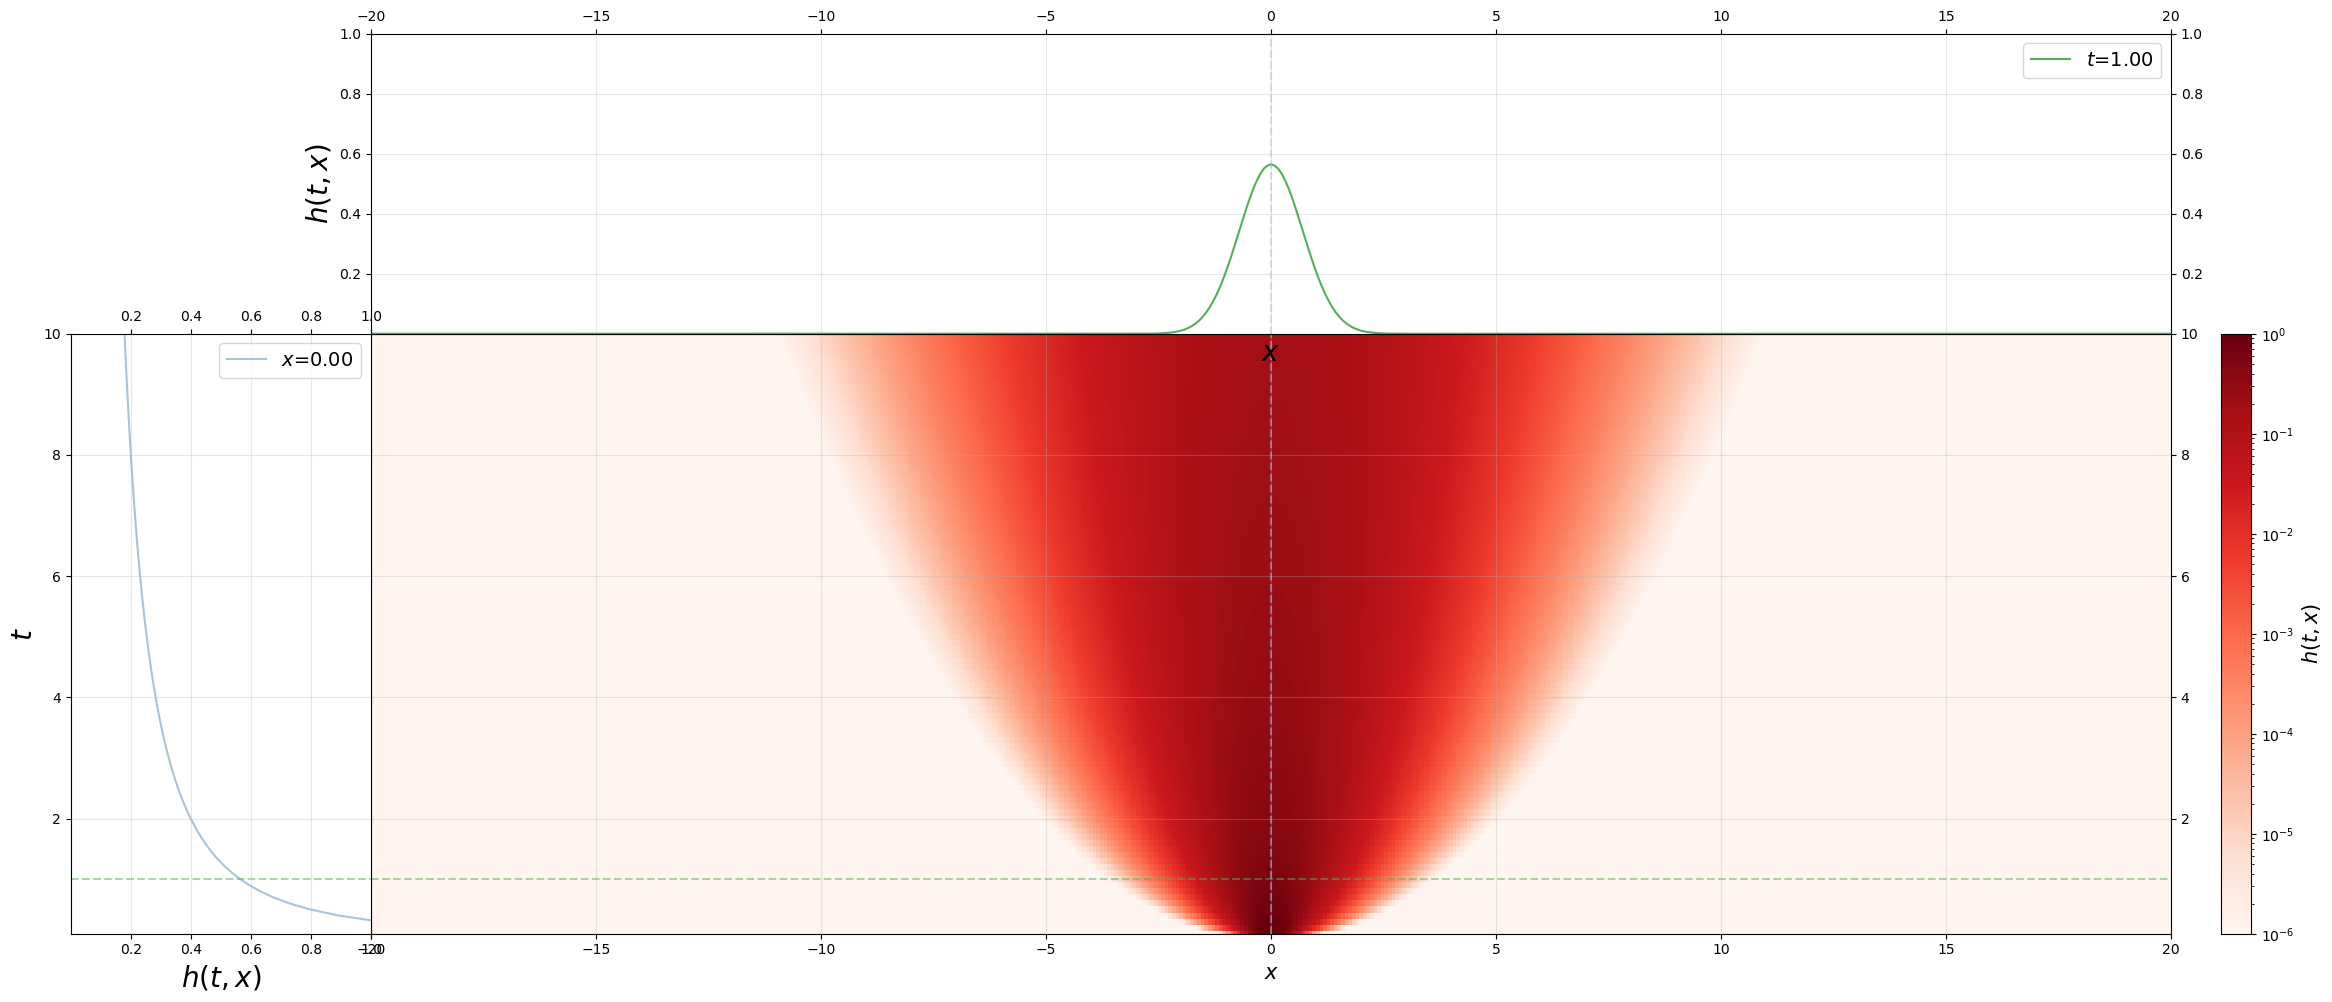

In [5]:
plot_2D_field(
    field_1.T,
    x_coordinate=x_coordinate,y_coordinate=t_coordinate,
    label=r'$h(t,x)$',xlabel=r'$x$',ylabel=r'$t$',
    vmin=1e-6,vmax=1.0,cmap='Reds',norm=LogNorm,
    plot_profile=True,profile_at_x=0,profile_at_y=1,
    return_fig=True,name='',working_dir='.'
)

In [6]:
pad_width_each_axis=(2000,)

In [7]:
spectrum, k_coordinate_each_axis, pad_slices=get_spectrum_from_field_with_coordinate(
    field=field_1,
    axis=1,
    r_coordinate_each_axis=[x_coordinate],
    pad_width_each_axis=pad_width_each_axis,
)

In [8]:
field_1_FFT=spectrum
kx_coordinate=k_coordinate_each_axis[0]

In [9]:
spectrum_theory=heat_FT(t_coordinate[:,jnp.newaxis],kx_coordinate[jnp.newaxis,:])

figure size= [24.3 11.5] inch
ax_main position= Bbox(x0=0.1646090534979424, y0=0.08695652173913043, x1=0.9053497942386831, y1=0.6086956521739131)


{'fig': <Figure size 2430x1150 with 4 Axes>,
 'ax_main': <Axes: xlabel='$k_x$', ylabel='$t$'>,
 'ax_panel_top': <Axes: xlabel='$k_x$', ylabel='$Phase  Fh(t,k_x)$'>,
 'ax_panel_left': <Axes: xlabel='$Phase  Fh(t,k_x)$', ylabel='$t$'>,
 'ax_cbar_0': <Axes: ylabel='$Phase  Fh(t,k_x)$'>,
 'ax_cbar': <Axes: ylabel='$Phase  Fh(t,k_x)$'>}

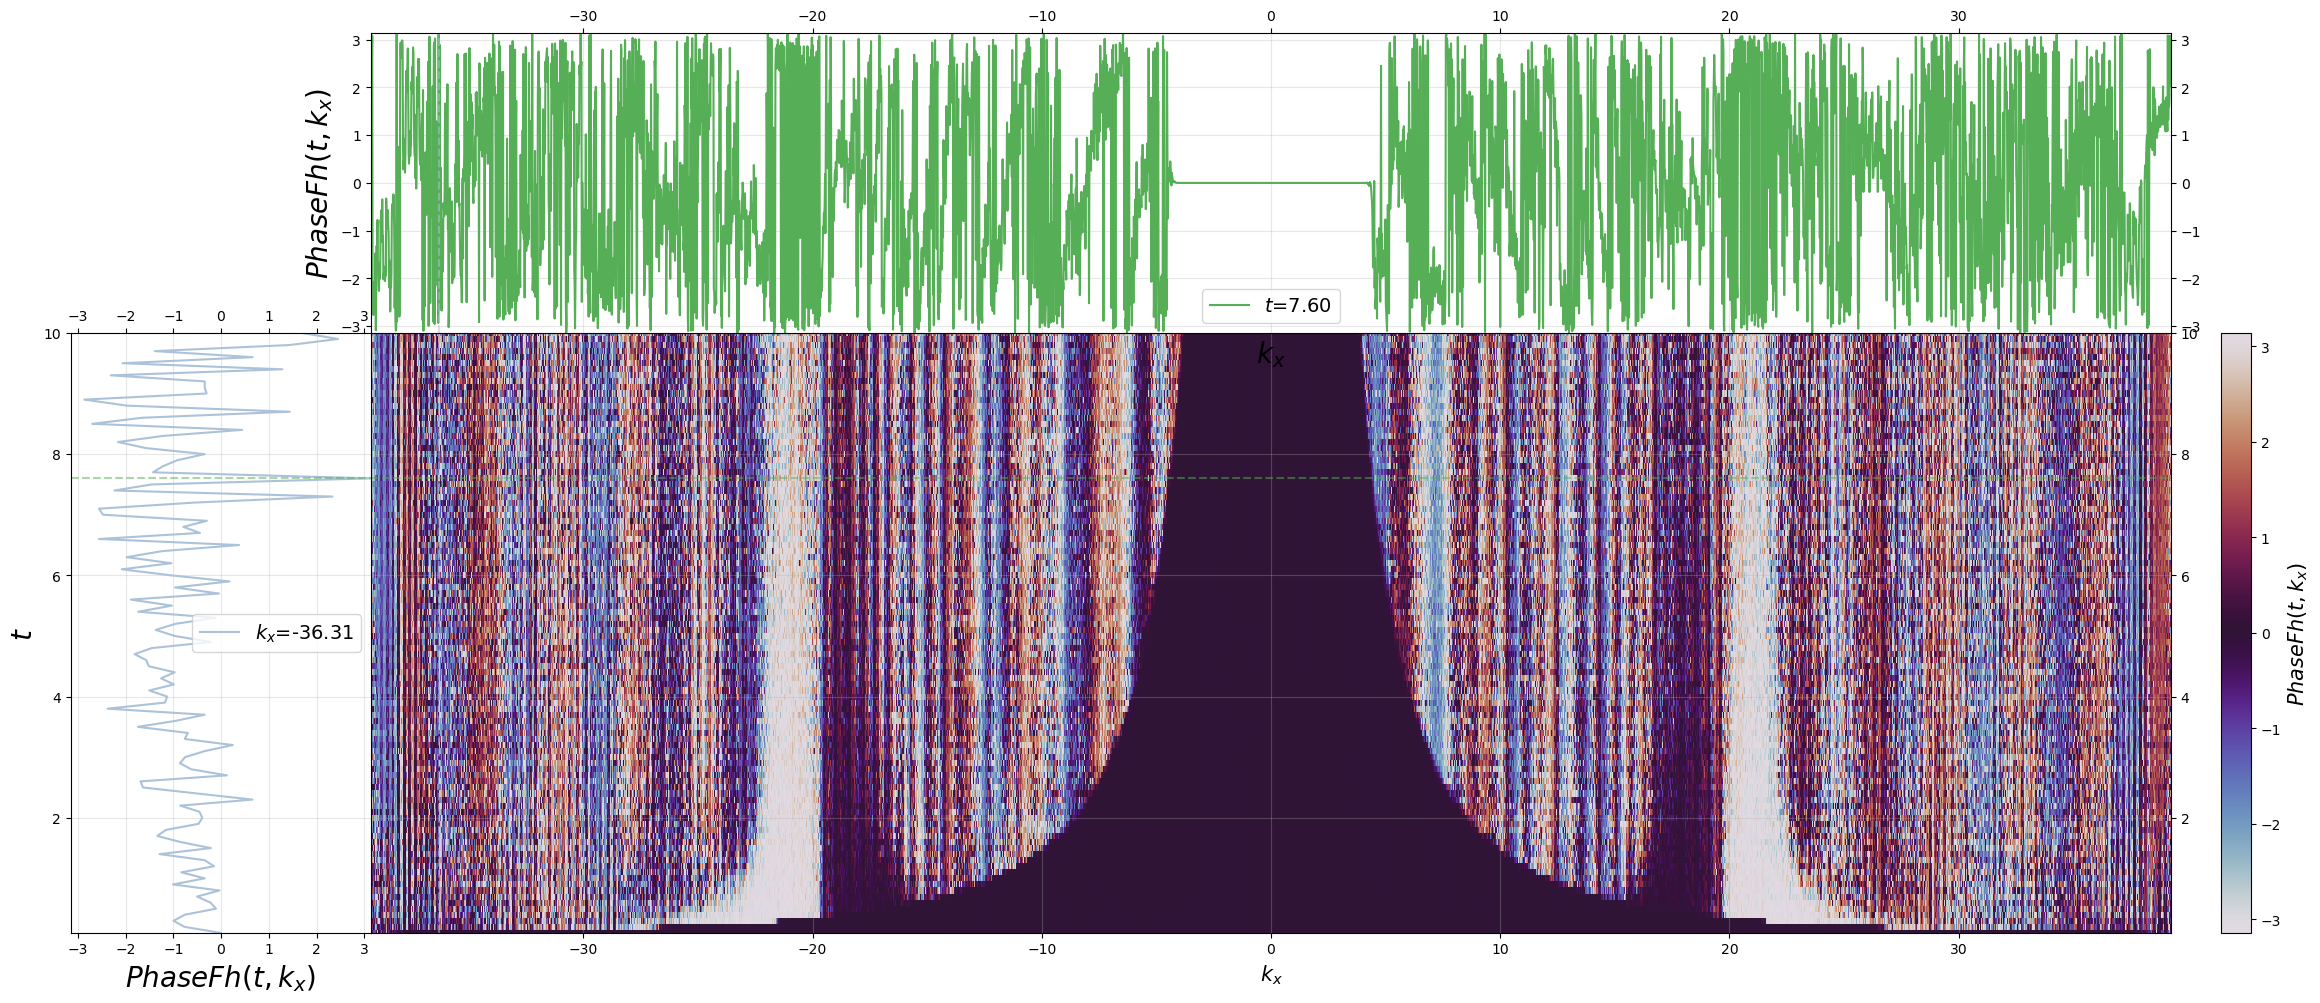

In [10]:
plot_2D_field(jnp.angle(field_1_FFT).T,x_coordinate=k_coordinate_each_axis[0],y_coordinate=t_coordinate,
    label=r'$Phase  Fh(t,k_x)$',xlabel=r'$k_x$',ylabel=r'$t$',
    vmin=-jnp.pi,vmax=jnp.pi,cmap='twilight',norm=Normalize,
)

figure size= [18.41941178 11.5       ] inch
ax_main position= Bbox(x0=0.2171622007757735, y0=0.08695652173913043, x1=0.8751317345539302, y1=0.6086956521739131)


{'fig': <Figure size 1841.94x1150 with 4 Axes>,
 'ax_main': <Axes: xlabel='$k_x$', ylabel='$t$'>,
 'ax_panel_top': <Axes: xlabel='$k_x$', ylabel='$|Fh(t,k_x)|^2$'>,
 'ax_panel_left': <Axes: xlabel='$|Fh(t,k_x)|^2$', ylabel='$t$'>,
 'ax_cbar_0': <Axes: ylabel='$|Fh(t,k_x)|^2$'>,
 'ax_cbar': <Axes: ylabel='$|Fh(t,k_x)|^2$'>}

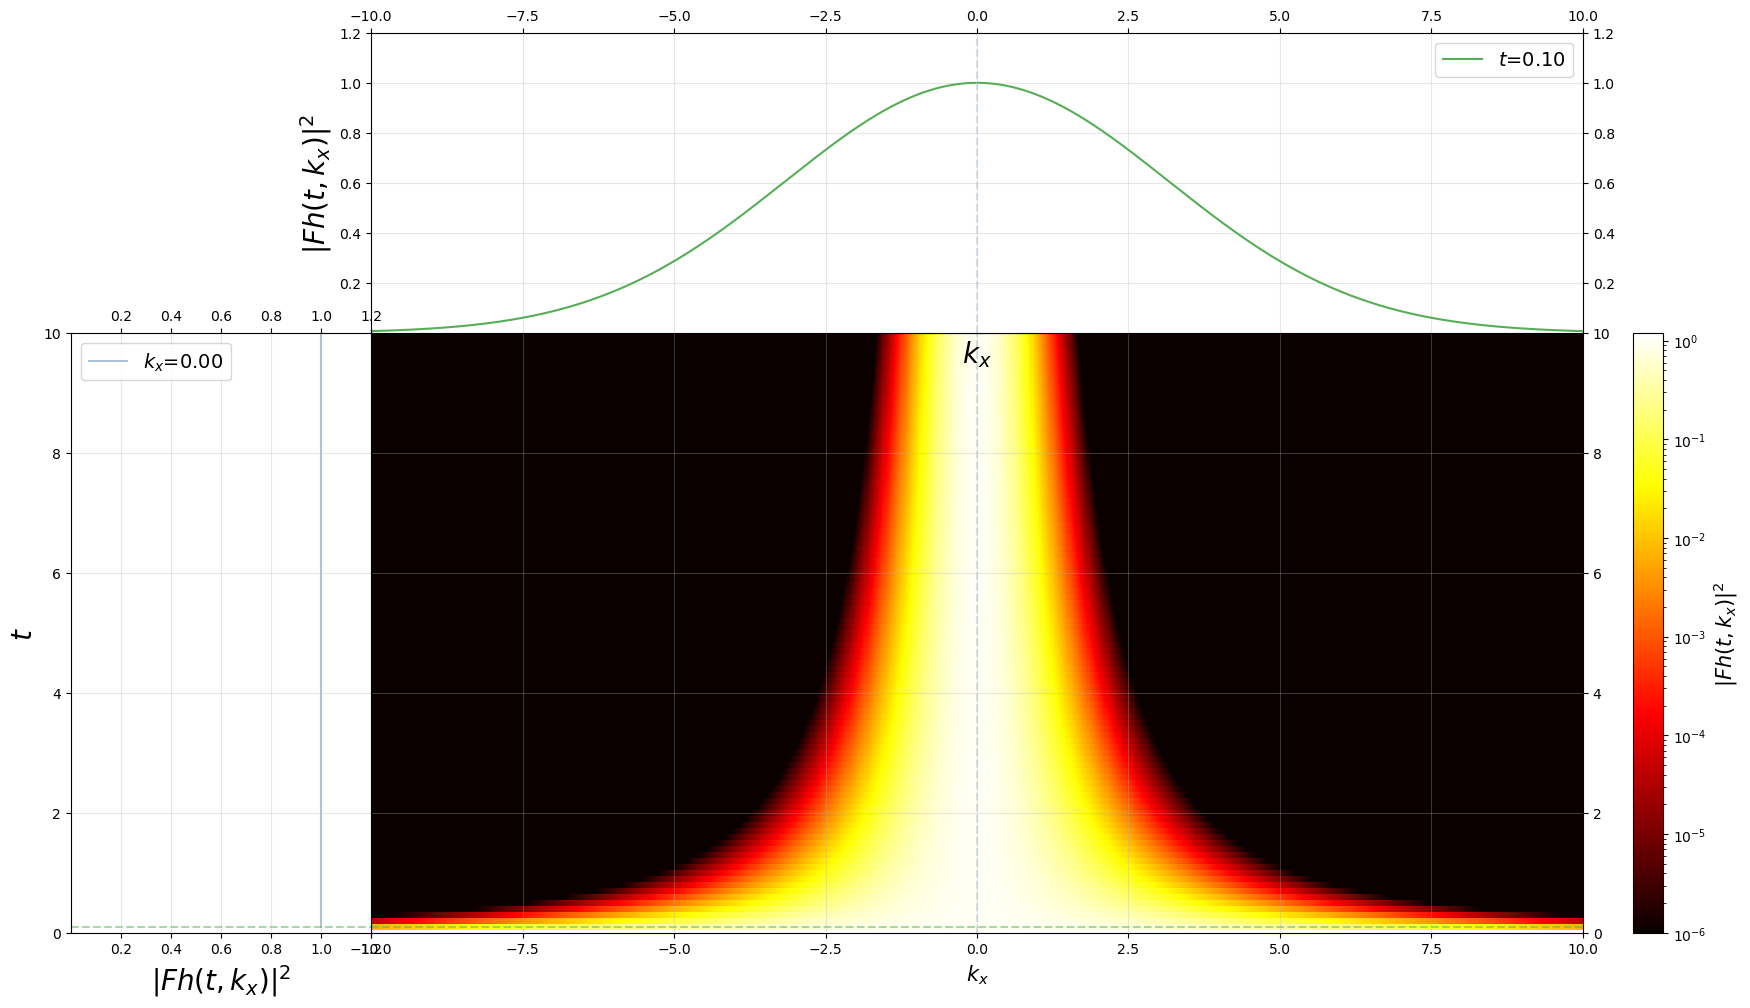

In [11]:
plot_2D_spectrum(
    spectrum_square=jnp.square(jnp.abs(spectrum)).T,
    kx_coordinate=k_coordinate_each_axis[0],
    ky_coordinate=t_coordinate,
    xlabel=r'$k_x$',ylabel=r'$t$',label=r'$|Fh(t,k_x)|^2$',
    kxmin=-10,kxmax=10,vmin=1e-6,vmax=1.2,cmap='hot',norm=LogNorm,
    profile_at_x=0,
)

In [12]:
spectrum_filter=filter_spectrum_by_k_coordinate(
    spectrum=field_1_FFT,
    k_coordinate_each_axis=k_coordinate_each_axis,
    axis=1,
    k_min=-1.0,
    k_max=1.0,
)

figure size= [18.41941178 11.5       ] inch
ax_main position= Bbox(x0=0.2171622007757735, y0=0.08695652173913043, x1=0.8751317345539302, y1=0.6086956521739131)


{'fig': <Figure size 1841.94x1150 with 4 Axes>,
 'ax_main': <Axes: xlabel='$k_x$', ylabel='$t$'>,
 'ax_panel_top': <Axes: xlabel='$k_x$', ylabel='$|Fh(t,k_x)|^2$'>,
 'ax_panel_left': <Axes: xlabel='$|Fh(t,k_x)|^2$', ylabel='$t$'>,
 'ax_cbar_0': <Axes: ylabel='$|Fh(t,k_x)|^2$'>,
 'ax_cbar': <Axes: ylabel='$|Fh(t,k_x)|^2$'>}

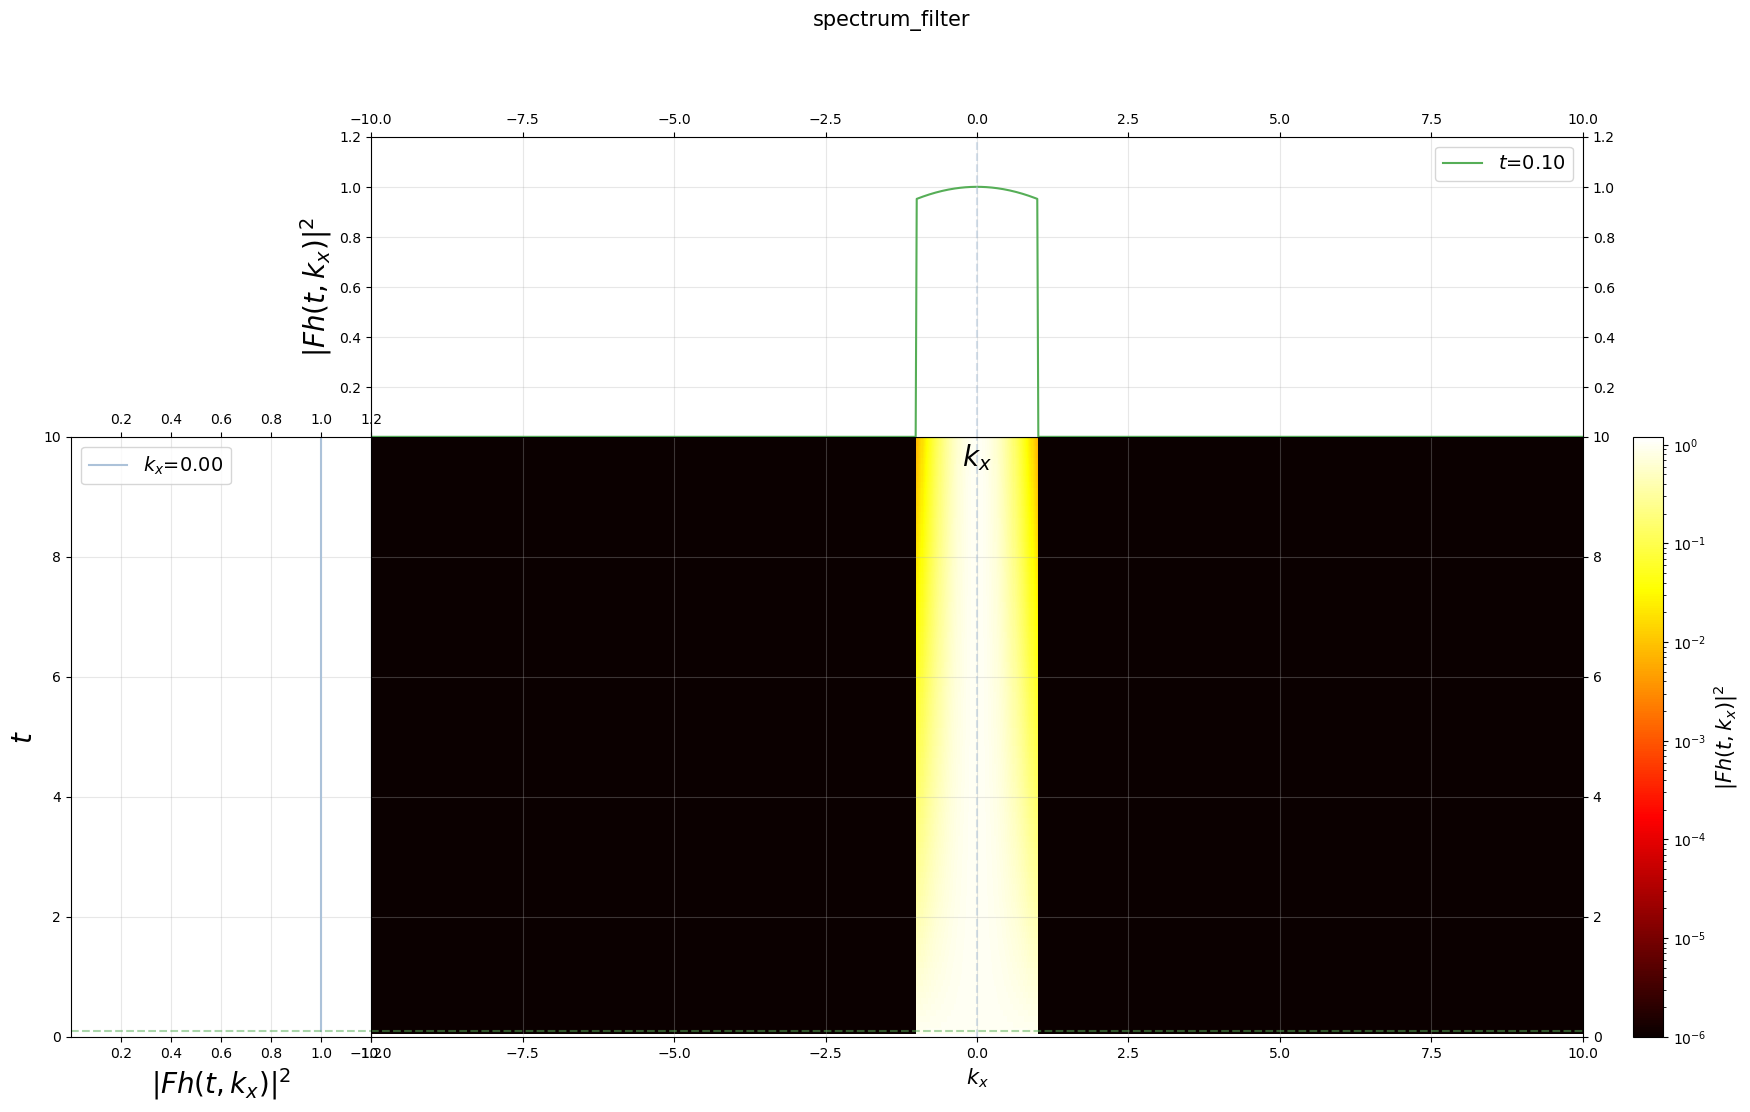

In [13]:
plot_2D_spectrum(
    spectrum_square=jnp.square(jnp.abs(spectrum_filter)).T,
    kx_coordinate=k_coordinate_each_axis[0],
    ky_coordinate=t_coordinate,
    xlabel=r'$k_x$',ylabel=r'$t$',label=r'$|Fh(t,k_x)|^2$',
    kxmin=-10,kxmax=10,vmin=1e-6,vmax=1.2,cmap='hot',norm=LogNorm,
    profile_at_x=0,name='spectrum_filter'
)

In [14]:
field_from_spectrum_theory=get_field_from_spectrum_with_coordinate(
    spectrum=spectrum_theory,
    k_coordinate_each_axis=k_coordinate_each_axis,
    axis=1,
    pad_width_each_axis=pad_width_each_axis
)

figure size= [24.3 11.5] inch
ax_main position= Bbox(x0=0.1646090534979424, y0=0.08695652173913043, x1=0.9053497942386831, y1=0.6086956521739131)


{'fig': <Figure size 2430x1150 with 4 Axes>,
 'ax_main': <Axes: xlabel='$x$', ylabel='$t$'>,
 'ax_panel_top': <Axes: xlabel='$x$', ylabel='$h(t,x)$'>,
 'ax_panel_left': <Axes: xlabel='$h(t,x)$', ylabel='$t$'>,
 'ax_cbar_0': <Axes: ylabel='$h(t,x)$'>,
 'ax_cbar': <Axes: ylabel='$h(t,x)$'>}

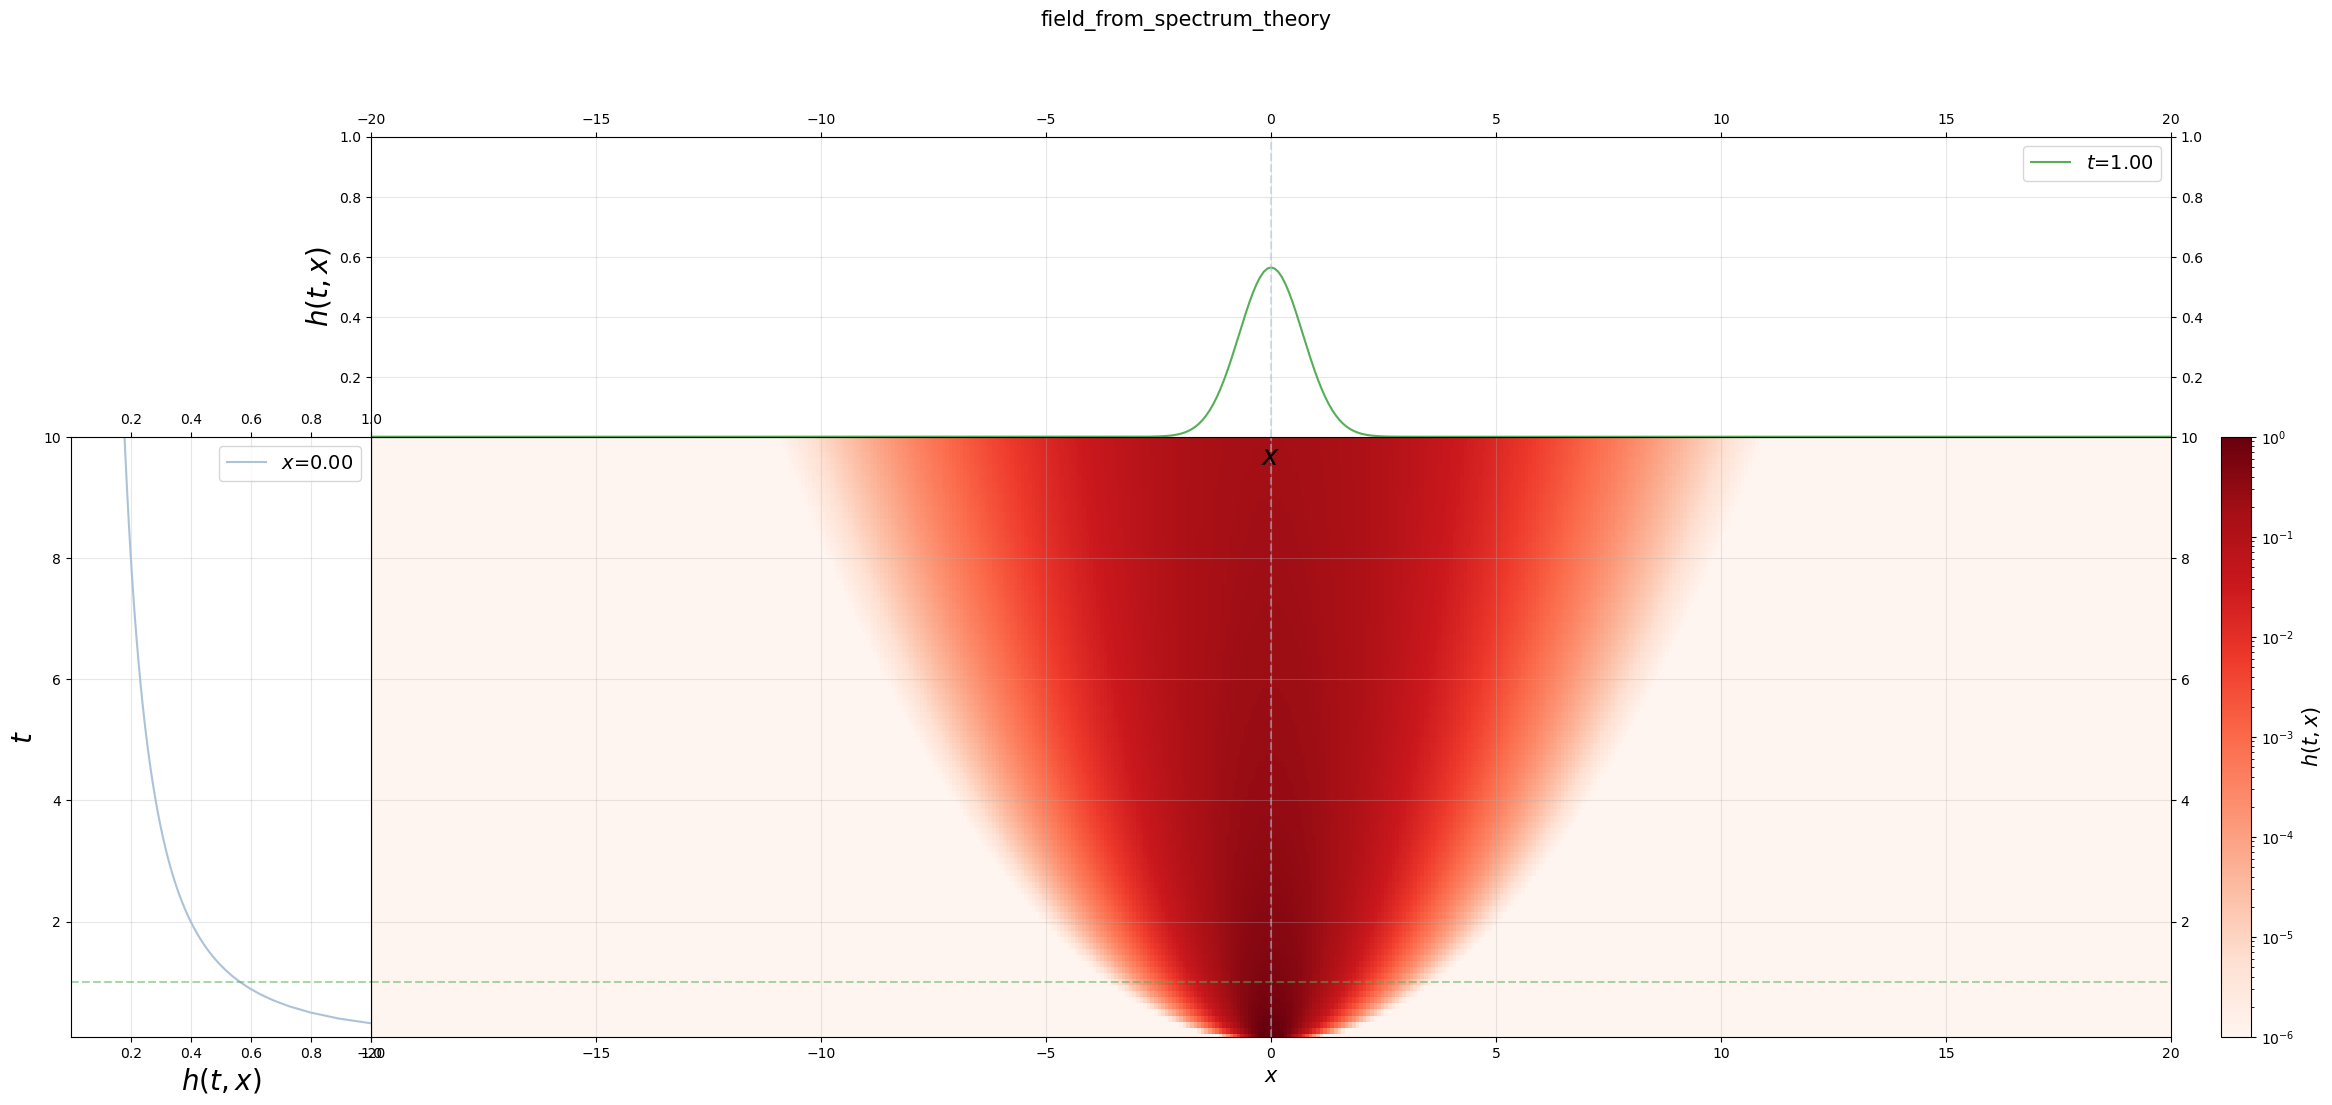

In [15]:
plot_2D_field(
    field_from_spectrum_theory.T,
    x_coordinate=x_coordinate,y_coordinate=t_coordinate,
    label=r'$h(t,x)$',xlabel=r'$x$',ylabel=r'$t$',
    vmin=1e-6,vmax=1.0,cmap='Reds',norm=LogNorm,
    plot_profile=True,profile_at_x=0,profile_at_y=1,
    return_fig=True,name='field_from_spectrum_theory',
)

In [16]:
field_from_spectrum_filter=get_field_from_spectrum_with_coordinate(
    spectrum=spectrum_filter,
    k_coordinate_each_axis=k_coordinate_each_axis,
    axis=1,
    pad_width_each_axis=pad_width_each_axis
)

figure size= [24.3 11.5] inch
ax_main position= Bbox(x0=0.1646090534979424, y0=0.08695652173913043, x1=0.9053497942386831, y1=0.6086956521739131)


{'fig': <Figure size 2430x1150 with 4 Axes>,
 'ax_main': <Axes: xlabel='$x$', ylabel='$t$'>,
 'ax_panel_top': <Axes: xlabel='$x$', ylabel='$h(t,x)$'>,
 'ax_panel_left': <Axes: xlabel='$h(t,x)$', ylabel='$t$'>,
 'ax_cbar_0': <Axes: ylabel='$h(t,x)$'>,
 'ax_cbar': <Axes: ylabel='$h(t,x)$'>}

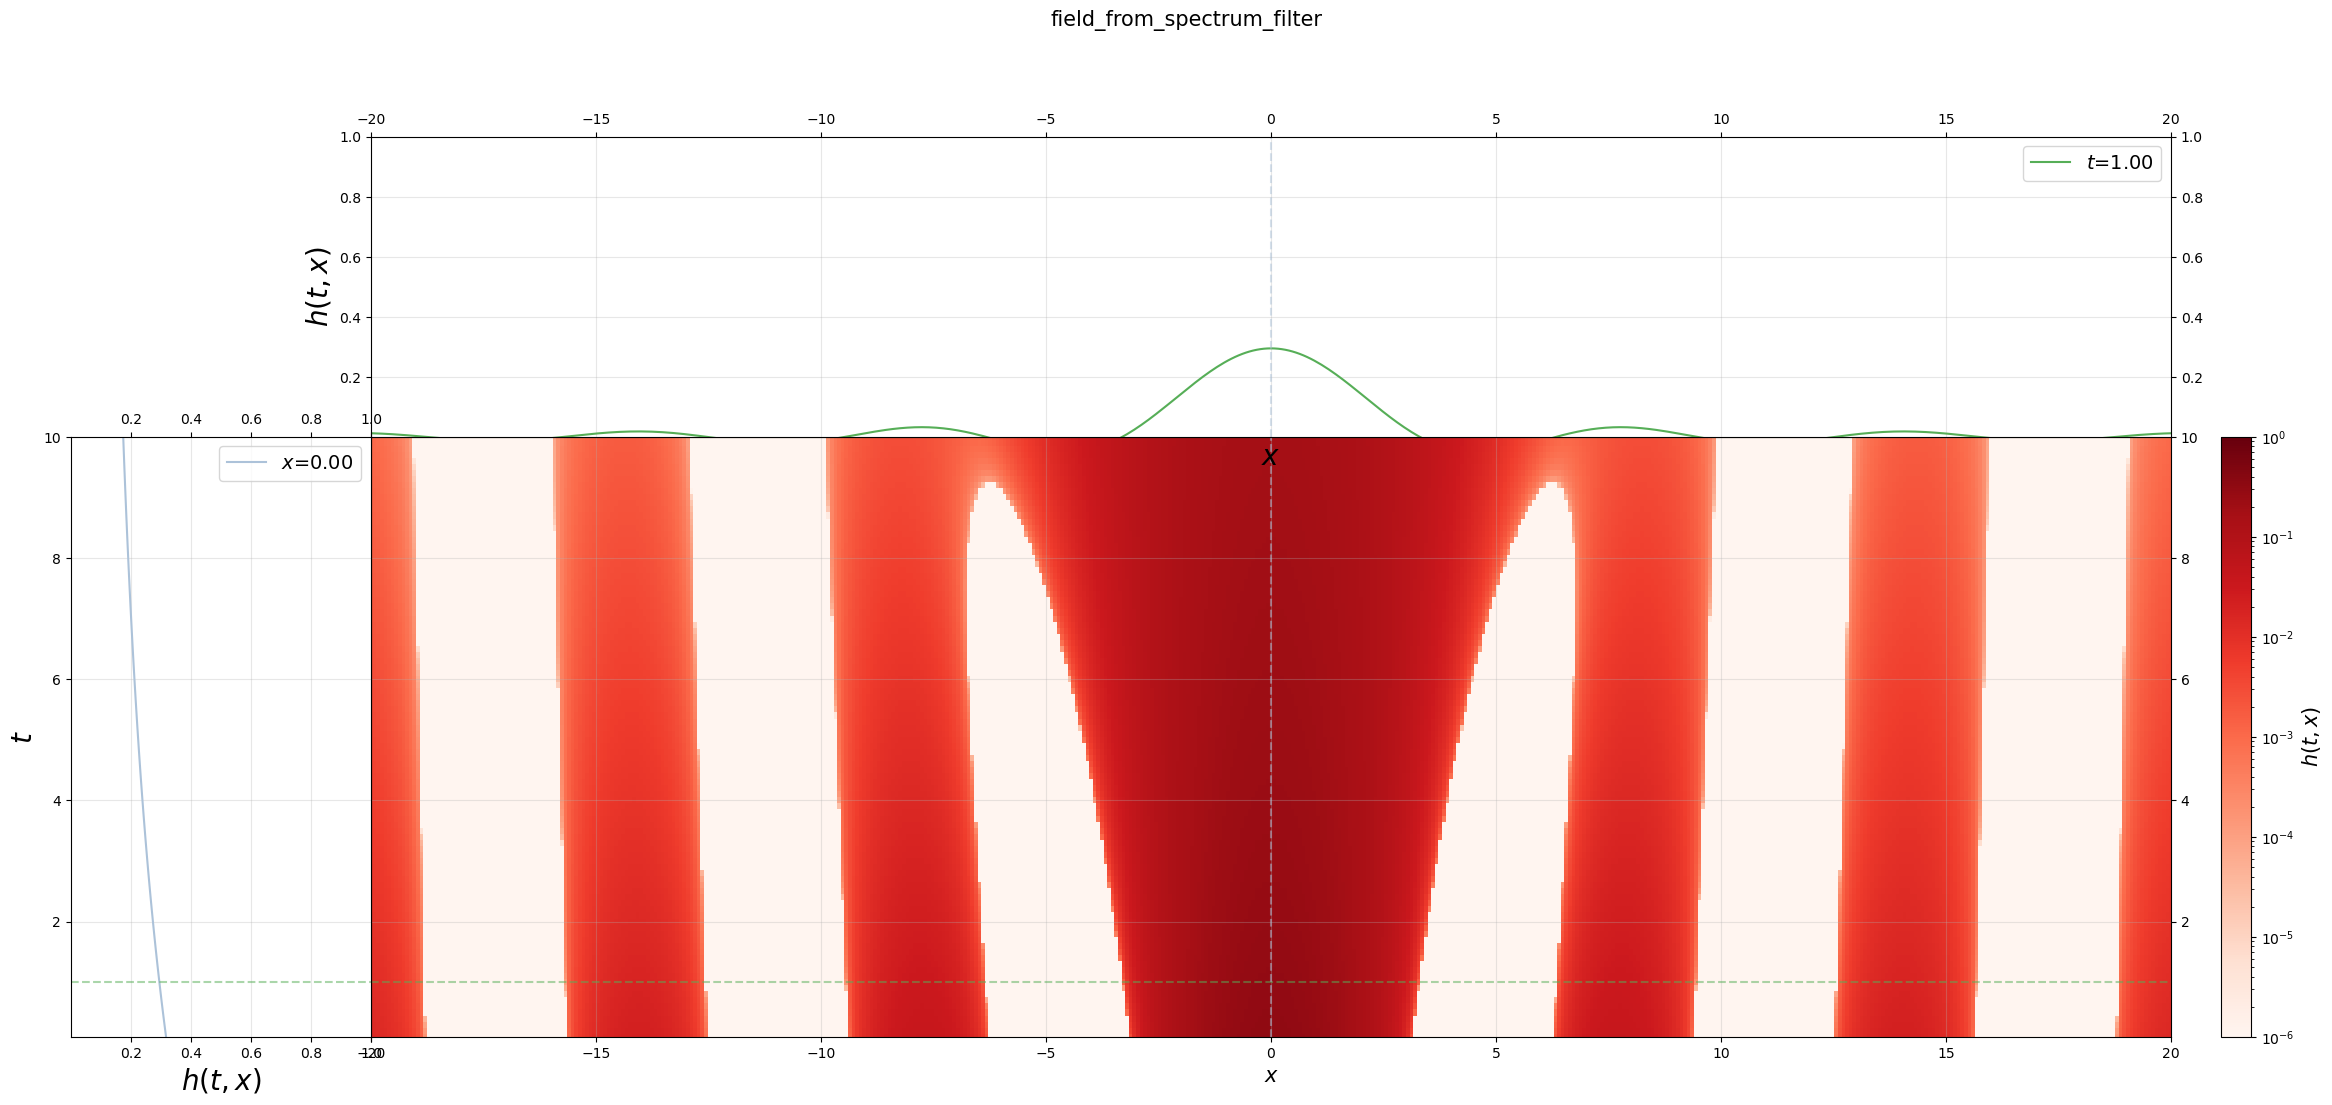

In [17]:
plot_2D_field(
    field_from_spectrum_filter.T,
    x_coordinate=x_coordinate,y_coordinate=t_coordinate,
    label=r'$h(t,x)$',xlabel=r'$x$',ylabel=r'$t$',
    vmin=1e-6,vmax=1.0,cmap='Reds',norm=LogNorm,
    plot_profile=True,profile_at_x=0,profile_at_y=1,
    return_fig=True,name='field_from_spectrum_filter',
)